In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB, ComplementNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score ,classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS, CountVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from collections import Counter
import time
import warnings

## 1. Loading The Data
We start by loading the 20 newsgroups dataset's raw text data and insepct it to see what are we going to work with.

In [2]:
# Load the data as is from the 20 newsgroups dataset.
train_data_raw = fetch_20newsgroups(subset='train', shuffle=True, random_state=42)

Let's have a look at two randomly chosen example documents of the original raw data.

In [3]:
# Save some example documents (chosen randomly, can change the index to see other documents).
example_document1 = train_data_raw.data[39]
example_document2 = train_data_raw.data[40]

print('1st Example:\n',example_document1)
print('2nd Example:\n',example_document2)

1st Example:
 From: bressler@iftccu.ca.boeing.com (Rick Bressler)
Subject: Re: Gun Lovers (was Re: My Gun is like my American Express Card)
Organization: Boeing Commercial Airplane Group
Lines: 104

/ iftccu:talk.politics.guns / vincent@cad.gatech.edu (Vincent Fox) / 10:34 am  Apr 14, 1993 /

This isn't rec.guns, so maybe this is getting a bet technical, but I
can't resist....

> - A revolver also has the advantage that if it misfires you just pull
>   the trigger again.

Sometimes.....  Depends on WHY it misfired....

> - A double-action revolver (almost all of them) can be hand-cocked first,
>   but will fire merely by pulling the trigger.

I can't imagine doing much combat type shooting single action.....

> - A misfire in a revolver merely means you must pull the trigger again
>   to rotate to the next round.

Assuming the cylinder WILL rotate....

> - A revolver can be carried with the 6th chamber empty and under the
>   hammer for maximum safety, but still can be drawn and fired 

By examining the examples of the original raw data, We noticed that headers, footers, and quoted text contain a lot of irrelevant information that could mislead the classifier or information. Headers often include metadata such as sender names, email addresses, and server details, which do not contribute to the actual topic of discussion. Footers usually contain signatures, which may introduce bias, and quoted text repeats parts of previous messages, creating redundancy. Keeping these elements could cause the model to overfit to superficial patterns rather than meaningful content. 
To ensure the classifier learns from the content of the document itself, we will use the remove parameter to exclude these elements when loading the training and test data.

In [4]:
# Load the 20 Newsgroups dataset's training set with headers, footers, and quotes removed.
train_data = fetch_20newsgroups(subset='train', 
                                shuffle=True, 
                                random_state=42,
                                remove =("headers","footers","quotes"),
                               )

# Load the 20 Newsgroups dataset's testing set with headers, footers, and quotes removed.
test_data = fetch_20newsgroups(subset='test',
                               shuffle=True,
                               random_state=42,
                               remove=("headers","footers","quotes"),
                              )

# Get the raw documents and labels.
X_train, y_train = train_data.data, train_data.target
X_test, y_test = test_data.data, test_data.target

# Target names (class labels):
target_names = train_data.target_names
print('We can see that our 18,846 samples are divided as follows:')
print('Training data samples -',len(X_train))
print('Testing data samples -',len(X_test))
print('Number of classes -',len(target_names))


We can see that our 18,846 samples are divided as follows:
Training data samples - 11314
Testing data samples - 7532
Number of classes - 20


## 2. Data distribution
It's interesting to see how does the data is distributed to different classes, and how does the raw data looks like.

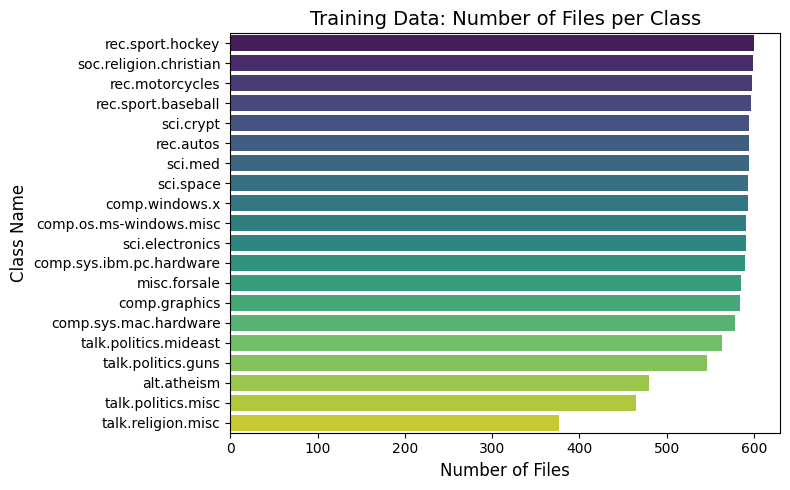

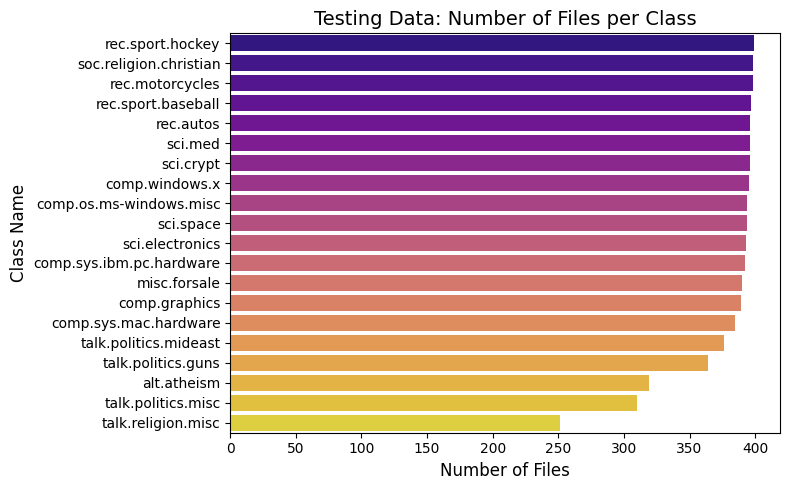

In [5]:
# Count the number of files in each class for the training data
train_class_counts = Counter(y_train)
test_class_counts = Counter(y_test)

# Create a bar plot to visualize the file counts per class
sorted_counts = sorted(train_class_counts.items(), key=lambda x: x[1], reverse=True)
classes = [target_names[idx] for idx, _ in sorted_counts]
counts = [count for _, count in sorted_counts]

sorted_counts_test = sorted(test_class_counts.items(), key=lambda x: x[1], reverse=True)
classes_test = [target_names[idx] for idx, _ in sorted_counts_test]
counts_test = [count for _, count in sorted_counts_test]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts, y=classes, hue=classes, palette="viridis", dodge=False)
plt.xlabel("Number of Files", fontsize=12)
plt.ylabel("Class Name", fontsize=12)
plt.title("Training Data: Number of Files per Class", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()  # Adjust layout so that long class names fit
plt.show()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts_test, y=classes_test, hue=classes_test, palette="plasma", dodge=False)
plt.xlabel("Number of Files", fontsize=12)
plt.ylabel("Class Name", fontsize=12)
plt.title("Testing Data: Number of Files per Class", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()  # Adjust layout so that long class names fit
plt.show()

The data is quite balanced in the most part, However there are some classes("talk.religion.misc" (377 files), "talk.politics.misc" (465 files) and "alt.etheism" (480 files)) that have fewer files compared to the other classes which are around 600 files each. This might lead to higher accuracy on majority classes while underpreforming on minority classes when using Algorithms like Logistic Regression and SVM which optimize a global loss. same thing might happen with kNN and Decision Trees. 
We will see about that later in the project.

## 3. Preprocessing
We can see that our original raw data contains a lot of noise such as punctuation, numbers and special characters. 
As Tf-idf vectorizer will represent the data as a sparse matrix, if we wont remove the noise factors, they will add unnecessary dimensions that do not contribute to meaning and will increase computational cost without meaningful gains.
Also, extra noise can cause models to learn irrelevant patterns, making them less effective.
Another thing is that the data contains stop words(e.g., "the", "is", "and") which are common across all the data, meaning they do not help in distinguishing between categories so keeping them increase noise and will overshadow more meaningful words.

Concluding our wanted Preprocessing steps to execute:
1. Cleaning - Convert text to lowercase (treat "Apple" and "apple" as the same word) and remove punctuation, numbers and special characters.
4. Stopwords Removal - we will filter out common stopwords.
3. Tokenization - Using tf-idf vectorized we will convert the raw data into vectors.
5. Stemming - converting words to their base form, Changing Changed Change will turn into Chang.

In [6]:
# Define a custom analyzer function that will be used to preprocess the text data.
def custom_analyzer(text):
    # 1. Cleaning & Lowercasing: Convert text to lowercase and remove non-word characters.
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)
    
    # 2. Tokenization: Tokenize the cleaned text.
    tokens = word_tokenize(text)
    # 3. Stopwords Removal: Filter out common English stopwords.
    tokens = [token for token in tokens if token not in ENGLISH_STOP_WORDS]
    
    # 4. Stemming: Convert tokens to their base form using PorterStemmer.
    stemmer = PorterStemmer()
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    
    return stemmed_tokens


# Create a TF-IDF Vectorizer with the custom analyzer.
tfidf_vect = TfidfVectorizer(
    analyzer=custom_analyzer,  # use our custom analyzer function
    max_df=0.5,                # ignore terms that appear in more than 50% of the documents
    min_df=5,                   # ignore terms that appear in fewer than 5 documents
)

# Fit and transform the training data, then transform the testing data.
X_train_tfidf = tfidf_vect.fit_transform(X_train) # fit - learn the vocabulary and idf, transform - converting documents into document-term matrix
X_test_tfidf = tfidf_vect.transform(X_test) # transform - converting documents into document-term matrix based on the vocabulary and idf learned from the training data


count_vect = CountVectorizer(
    analyzer=custom_analyzer,  # use our custom analyzer function
    max_df=0.5,                # ignore terms that appear in more than 50% of the documents
    min_df=5,                   # ignore terms that appear in fewer than 5 documents
)

# Fit and transform the training data, then transform the testing data.
X_train_counts = count_vect.fit_transform(X_train)
X_test_counts = count_vect.transform(X_test)

print("CountVectorizer train data shape:", X_train_counts.shape)
print("CountVectorizer test data shape:", X_test_counts.shape)
print("TF-IDF train data shape:", X_train_tfidf.shape)
print("TF-IDF test data shape:", X_test_tfidf.shape)

# print an example of how a document is represented in the tf-idf matrix
print("Example of a document in the TF-IDF matrix:")
print(X_train_tfidf[0])

CountVectorizer train data shape: (11314, 13171)
CountVectorizer test data shape: (7532, 13171)
TF-IDF train data shape: (11314, 13171)
TF-IDF test data shape: (7532, 13171)
Example of a document in the TF-IDF matrix:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 32 stored elements and shape (1, 13171)>
  Coords	Values
  (0, 12819)	0.12786836724328807
  (0, 4723)	0.21163310816846242
  (0, 2942)	0.5017676791237605
  (0, 10392)	0.1431876120507329
  (0, 3931)	0.10762007509338402
  (0, 385)	0.08532607155327797
  (0, 4385)	0.3222193643213081
  (0, 11039)	0.16652940313827325
  (0, 7390)	0.18063814843491968
  (0, 7155)	0.1509166059743879
  (0, 993)	0.1491250761555914
  (0, 4532)	0.14374298945618083
  (0, 1125)	0.15975068184789182
  (0, 2887)	0.11059404346331207
  (0, 9775)	0.10188299749401727
  (0, 10830)	0.128608517427112
  (0, 1631)	0.13985514565608087
  (0, 2786)	0.2161418553076395
  (0, 10549)	0.1509166059743879
  (0, 10023)	0.13712161079334487
  (0, 2586)	0.14157991957042

## 4. Evaluation 
We want to see the performance of Logistic regression, Decision Tree, Random forest, LinearSVC, kNN and Naive Bayes on the data.
In order to do so we will wrap them all in a pipeline to run one by one in an organized way.

In [9]:
# Define the classifiers to test, the parameters each classifier gets are generic and not optimized.
classifiers = [
    ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000)),
    ('Ridge Classifier', RidgeClassifier(random_state=42, tol=1e-2, solver="sparse_cg")),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42, n_estimators=200)),
    ('LinearSVC', LinearSVC(random_state=42, dual="auto", max_iter=20000)), 
    ('KNN', KNeighborsClassifier(n_neighbors=7,metric="cosine",weights='distance')), # by default the metric is minkowski and weights is uniform
    ('Multinomial Naive Bayes', MultinomialNB()), 
    ('Complement Naive Bayes', ComplementNB())
]

classifiers_predictions = {}

# Function to evaluate a classifier and return metrics
def get_classifier_metrics(clf, X_train, X_test, y_train, y_test, clf_name, to_fit=True):
    start_time = time.time()
    
    # Train the classifier if asked to.
    if to_fit == True:
        clf.fit(X_train, y_train)
    
    training_time = time.time() - start_time
    # Make predictions.
    y_pred = clf.predict(X_test)
    classifiers_predictions[clf_name] = y_pred
    accuracy = accuracy_score(y_test, y_pred)*100
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)*100
    recall = recall_score(y_test, y_pred, average='weighted')*100
    f1 = f1_score(y_test, y_pred, average='weighted')*100
    
    return {
        'Classifier': clf_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time (s)': training_time,
        'y_pred': y_pred
    }

# def plot_confusion_matrix(y_true, y_pred, classifier_name, dataset_label):
#     plt.ioff()
#     # Compute the confusion matrix
#     cm = confusion_matrix(y_true, y_pred) 
#     # Create a figure and axis
#     fig, ax = plt.subplots(figsize=(8, 8))
    
#     # Plot the confusion matrix using Seaborn's heatmap, and use the target_names for tick labels
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
#                 ax=ax, xticklabels=target_names, yticklabels=target_names)
    
#     # Add title and axis labels
#     ax.set_title(f"Confusion Matrix: {classifier_name} ({dataset_label})", fontsize=16)
#     ax.set_xlabel("Predicted Label", fontsize=14)
#     ax.set_ylabel("Actual Label", fontsize=14)
    
#     return fig

def evaluate_classifiers(classifiers, X_train, X_test, y_train, y_test, dataset_label):
    """
    Evaluates each classifier on the given dataset, records the results, and also creates
    a confusion matrix plot for each classifier. Returns both the results and the list of
    confusion matrix figures.
    """
    results = []
    confusion_figures = []

    print(f"\n=== Running classifiers on {dataset_label} data ({X_train.shape[1]} features) ===\n")
    for clf_name, clf in classifiers:
        try:
            result = get_classifier_metrics(clf, X_train, X_test, y_train, y_test, clf_name)
            result['Dimensions'] = 'Original (No Reduction)'
            result['n_components'] = X_train.shape[1]
            results.append(result)
            print(f"Completed: {clf_name} on {dataset_label} data")
            # Create and store the confusion matrix figure for this classifier
            # fig = plot_confusion_matrix(y_test, result['y_pred'], clf_name, dataset_label)
            # confusion_figures.append(fig)
            
        except Exception as e:
            print(f"Error with {clf_name} on {dataset_label} data: {e}")
    return results #, confusion_figures

def format_results_table(df, groupby='n_components'):
    # Sort the results
    result_df = df.sort_values(by=[groupby, 'Accuracy'], ascending=[True, False]).copy()
    if 'y_pred' in result_df.columns:
        result_df.drop(columns=['y_pred'],inplace=True)
    return result_df


now let's evaluate the classifiers with tf-idf and countVectorizer, to see which one gives the better results.

In [10]:
# Evaluate classifiers on both TF-IDF and Count datasets
results_tfidf = evaluate_classifiers(classifiers, X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF")
# results_tfidf, confusion_figures_tfidf = evaluate_classifiers(classifiers, X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF")
# results_count, confusion_figures_count= evaluate_classifiers(classifiers, X_train_counts, X_test_counts, y_train, y_test, "Count")

# Convert the results list to DataFrames
results_df_tfidf = pd.DataFrame(results_tfidf)
# results_df_count = pd.DataFrame(results_count)

# Filter results for original dimensionality
original_results_tfidf = results_df_tfidf[results_df_tfidf['Dimensions'] == 'Original (No Reduction)']
# original_results_count = results_df_count[results_df_count['Dimensions'] == 'Original (No Reduction)']

# Format and display the TF-IDF results table
styled_df_tfidf = (
    format_results_table(original_results_tfidf, groupby='n_components').style \
    .set_caption("Results for Original TF-IDF Data") \
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    }))
display(styled_df_tfidf.hide())

# # Format and display the Count Vectorizer results table
# styled_df_count = format_results_table(original_results_count, groupby='n_components').style \
#     .set_caption("Results for Original Count Vectorizer Data") \
#     .format({
#         'Accuracy': '{:.2f}%',
#         'Precision': '{:.2f}%',
#         'Recall': '{:.2f}%',
#         'F1-Score': '{:.2f}%'
#     })

# display(styled_df_count.hide())



=== Running classifiers on TF-IDF data (13171 features) ===

Completed: Logistic Regression on TF-IDF data
Completed: Ridge Classifier on TF-IDF data
Completed: Decision Tree on TF-IDF data
Completed: Random Forest on TF-IDF data
Completed: LinearSVC on TF-IDF data
Completed: KNN on TF-IDF data
Completed: Multinomial Naive Bayes on TF-IDF data
Completed: Complement Naive Bayes on TF-IDF data


Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),Dimensions,n_components
Complement Naive Bayes,69.90%,70.72%,69.90%,69.48%,0.016510,Original (No Reduction),13171
Ridge Classifier,69.17%,69.69%,69.17%,69.10%,0.815297,Original (No Reduction),13171
Logistic Regression,68.37%,69.18%,68.37%,68.28%,2.936985,Original (No Reduction),13171
Multinomial Naive Bayes,68.14%,72.40%,68.14%,66.83%,0.026769,Original (No Reduction),13171
LinearSVC,67.83%,68.26%,67.83%,67.77%,0.561432,Original (No Reduction),13171
Random Forest,61.79%,61.36%,61.79%,60.99%,64.368844,Original (No Reduction),13171
KNN,58.98%,59.41%,58.98%,58.85%,0.003996,Original (No Reduction),13171
Decision Tree,43.80%,44.79%,43.80%,43.95%,8.662843,Original (No Reduction),13171


We see that with TF-IDF we got better results overall with only Decision Tree that preformed slightly better and kNN that went from 9.25% accuracy with tf-idf to 22.11% for countVectorizer.
So from this point on we will use the tf-idf vectorized data.

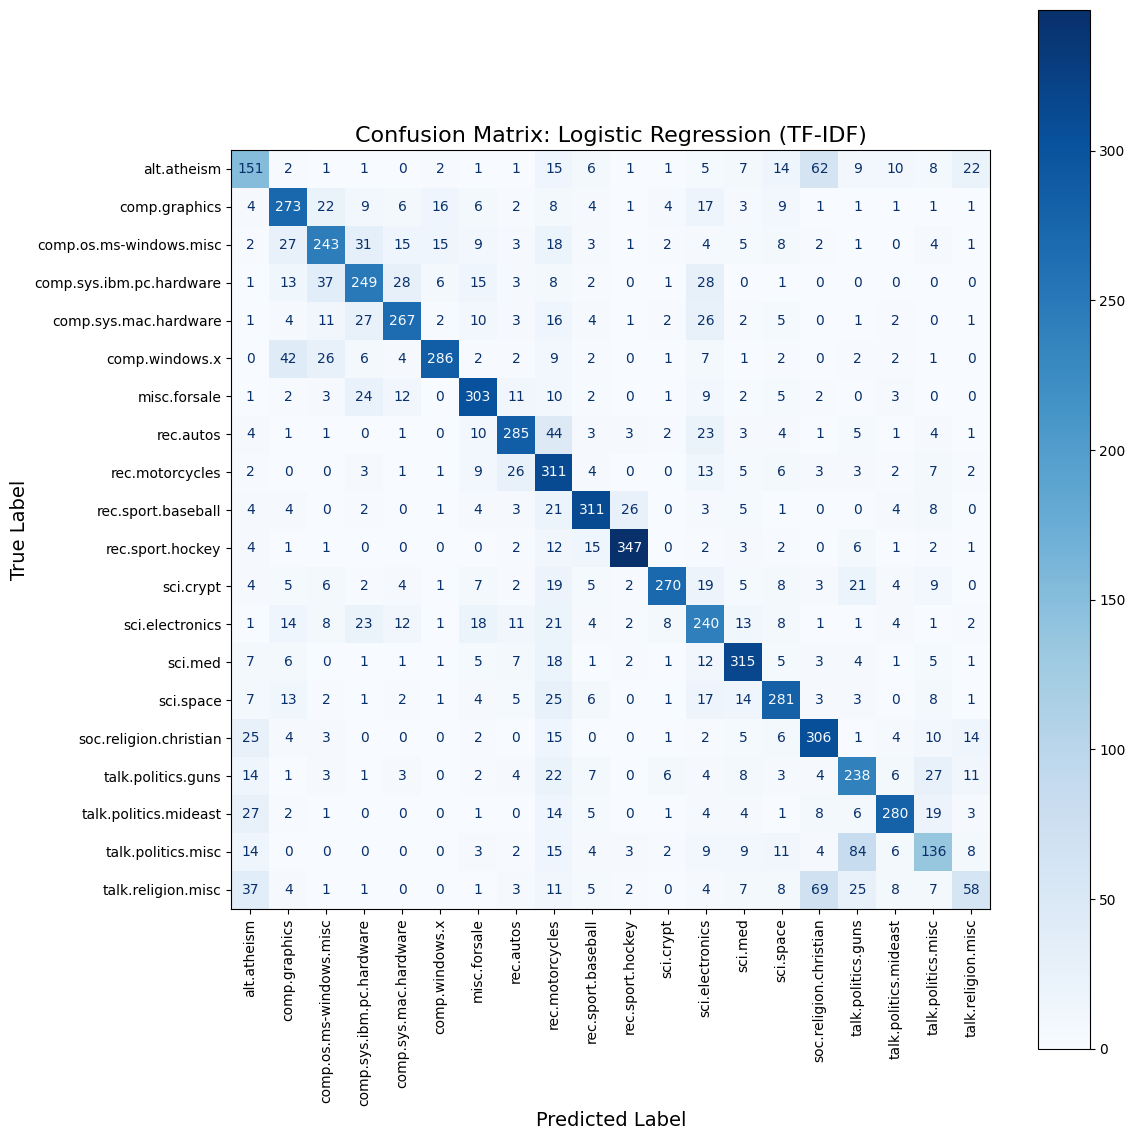

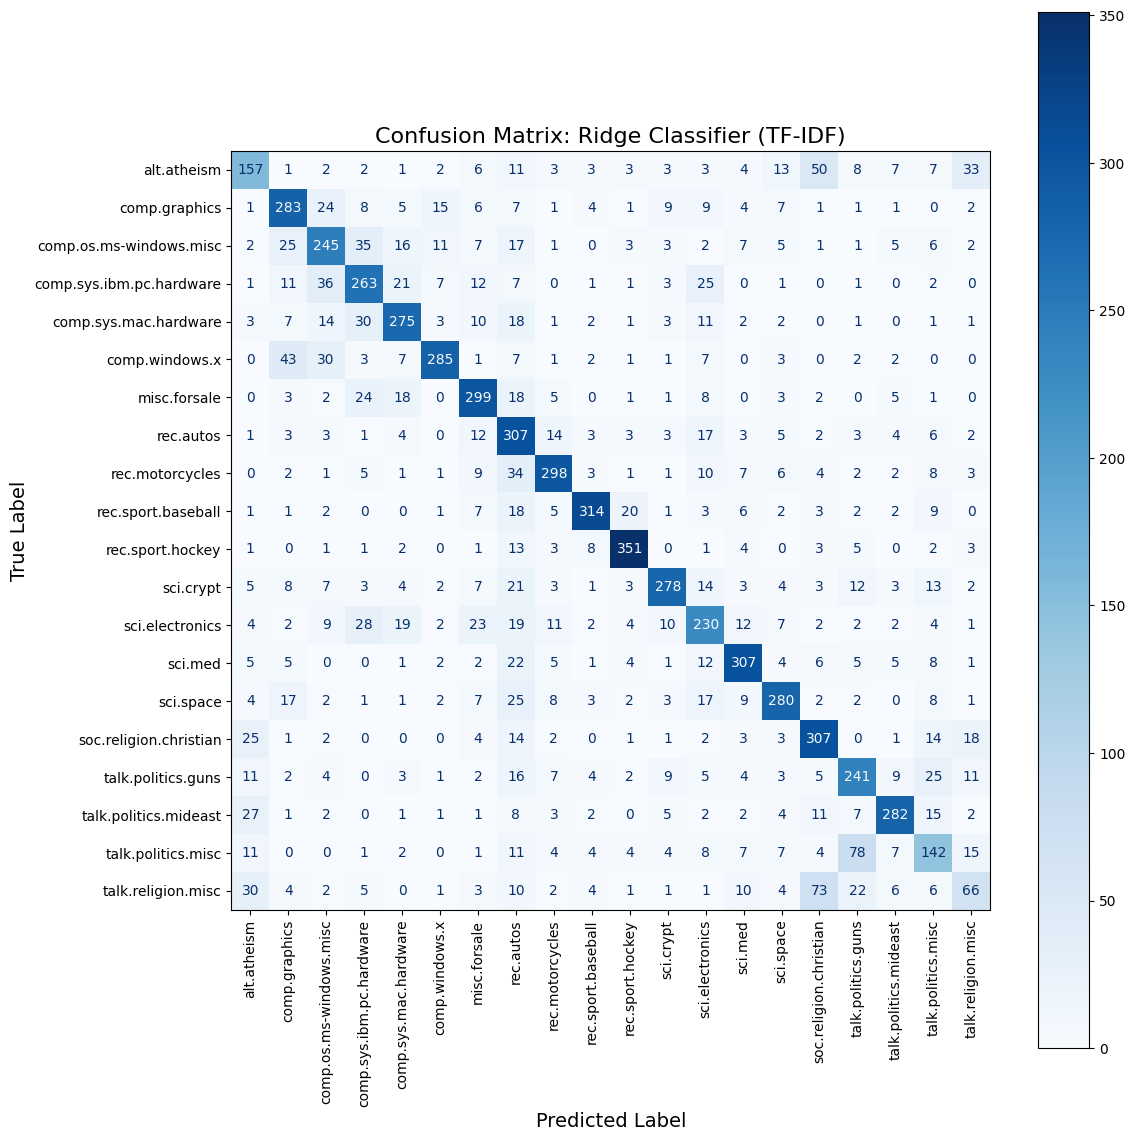

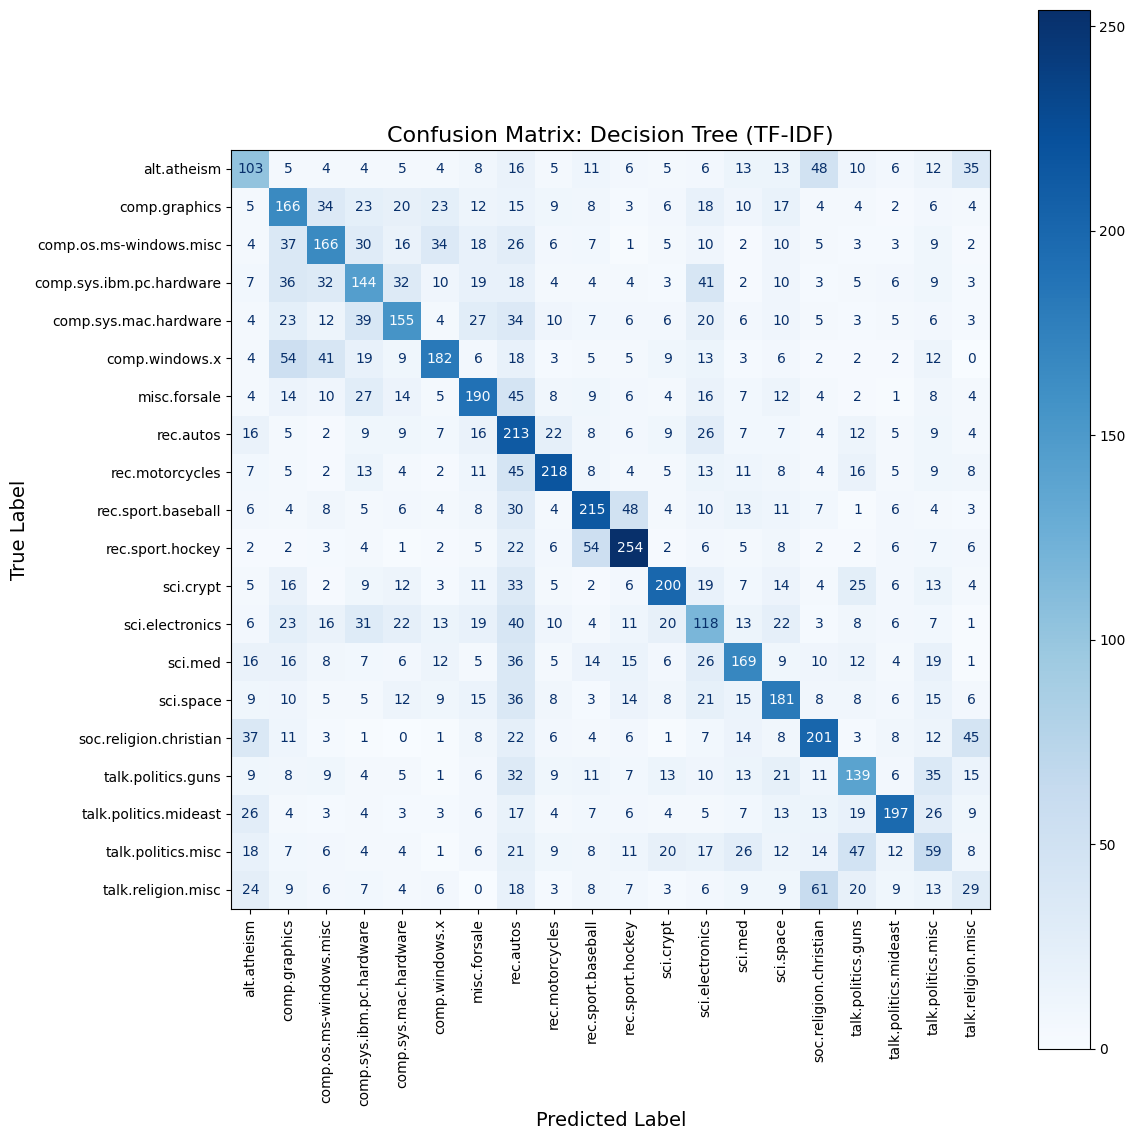

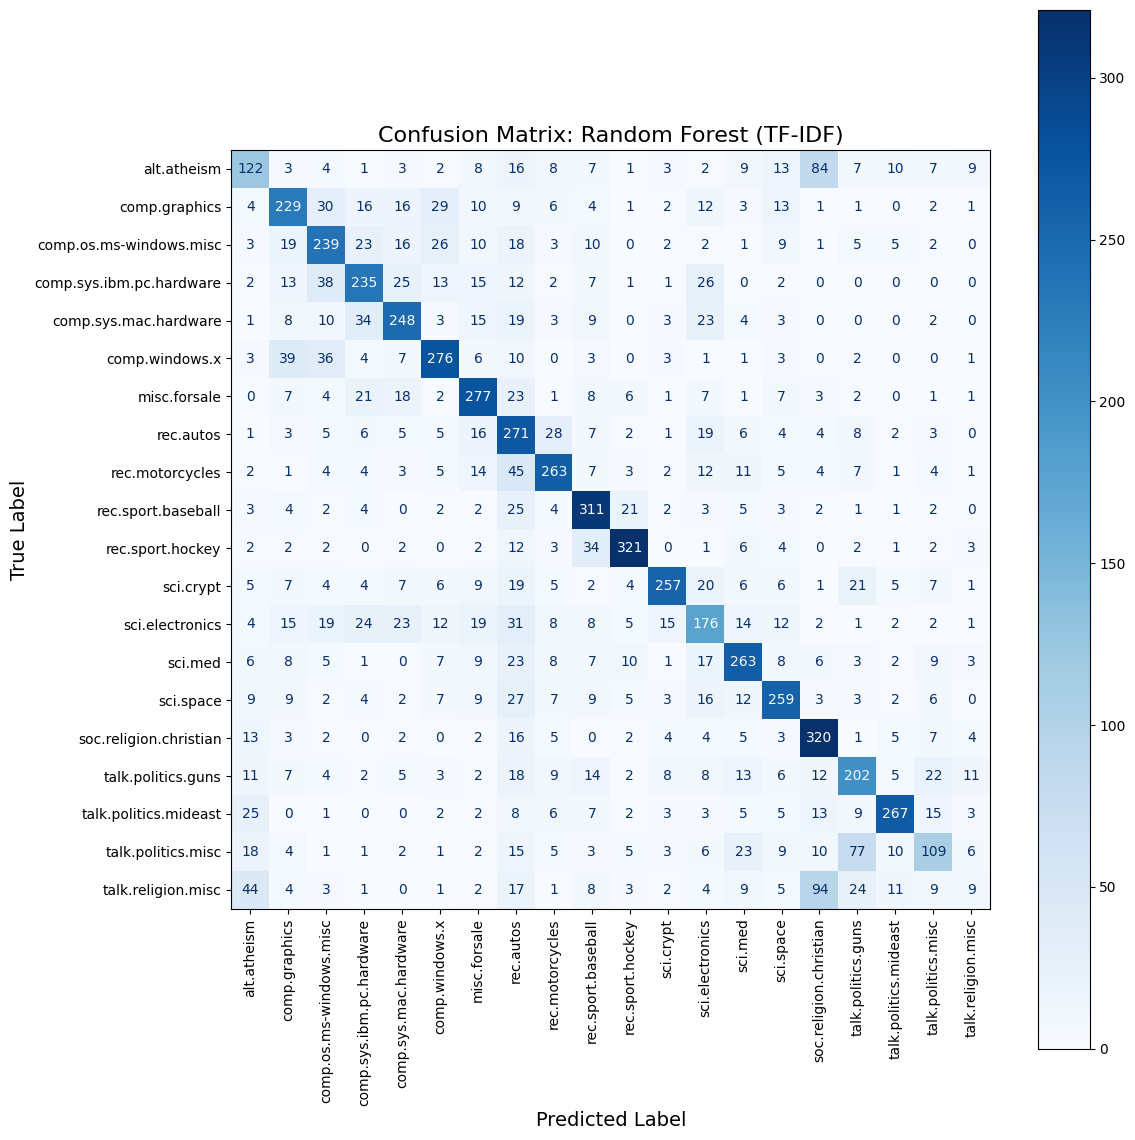

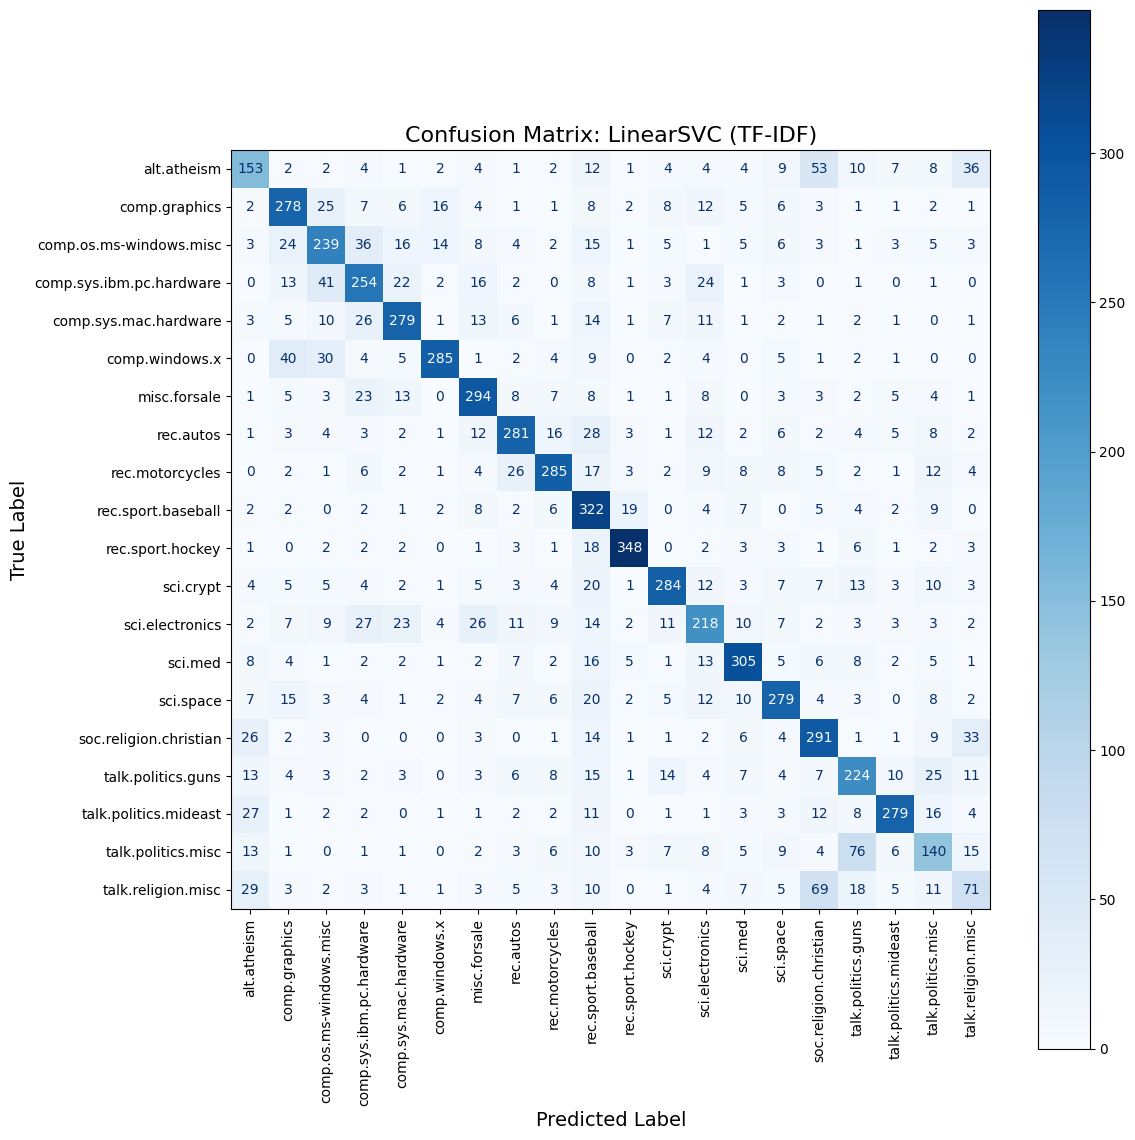

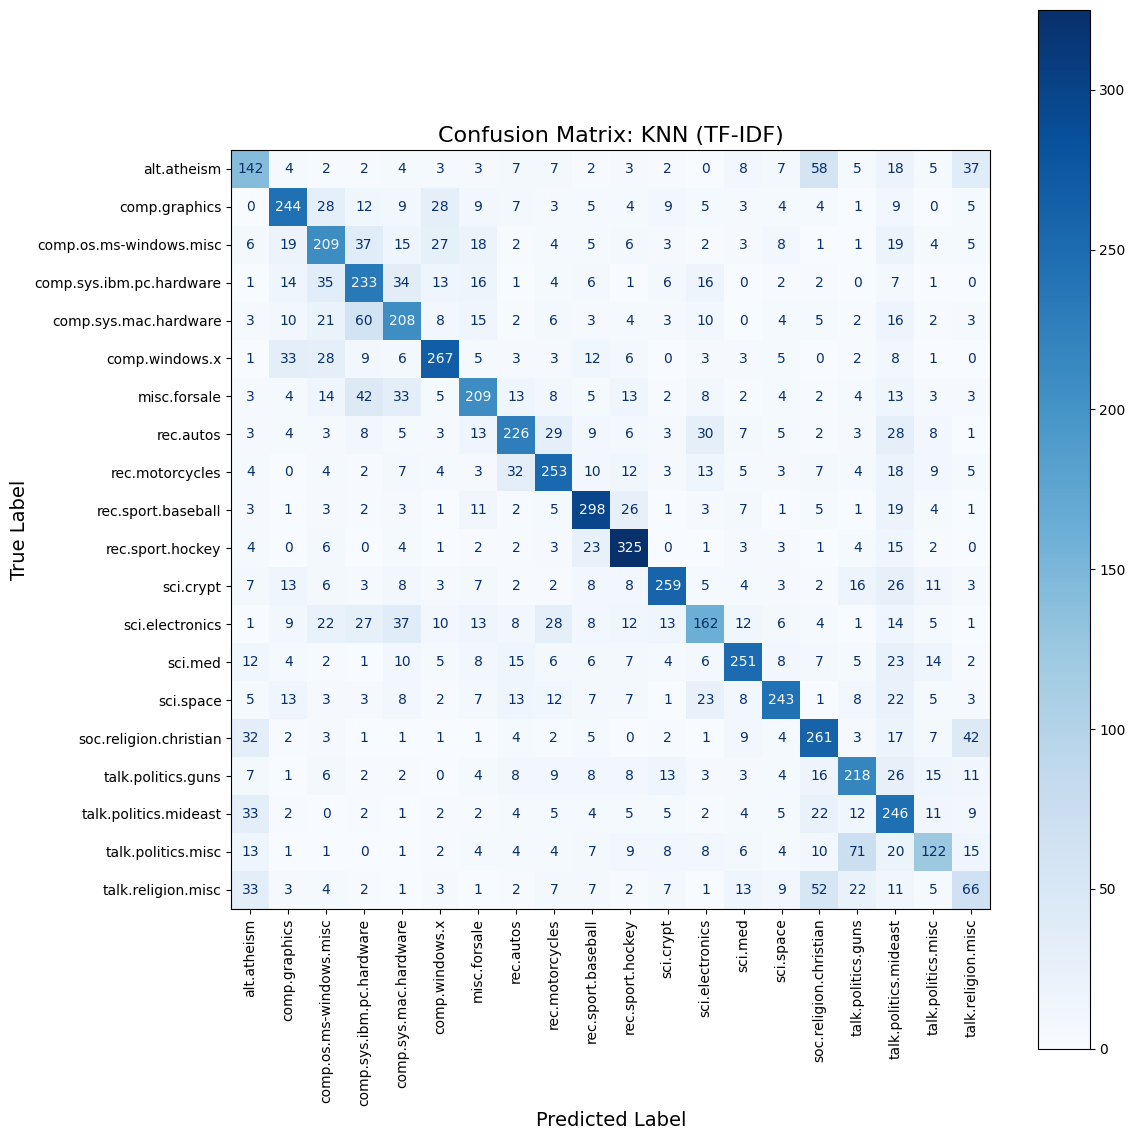

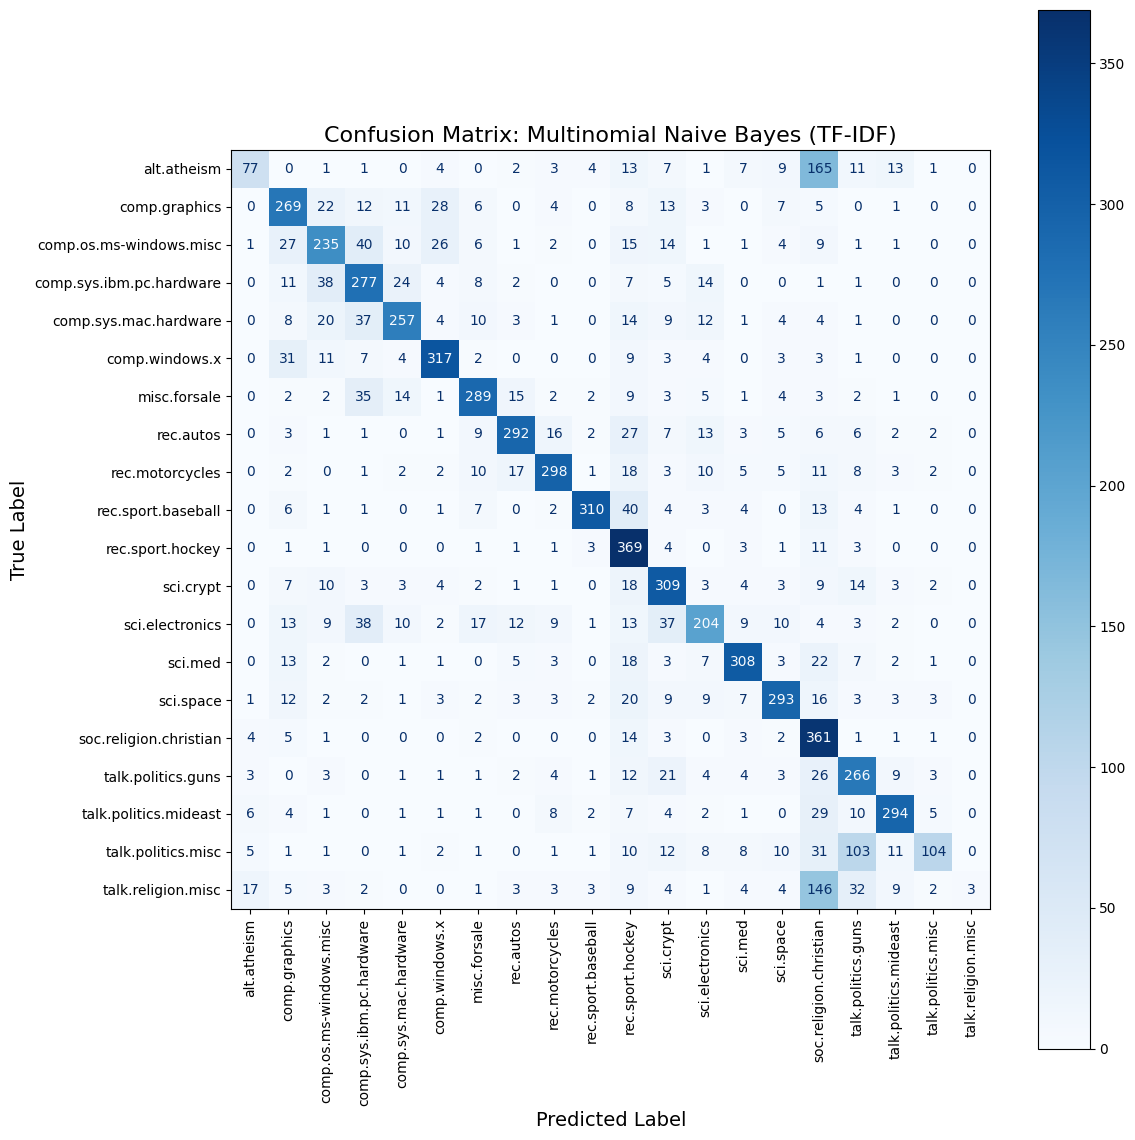

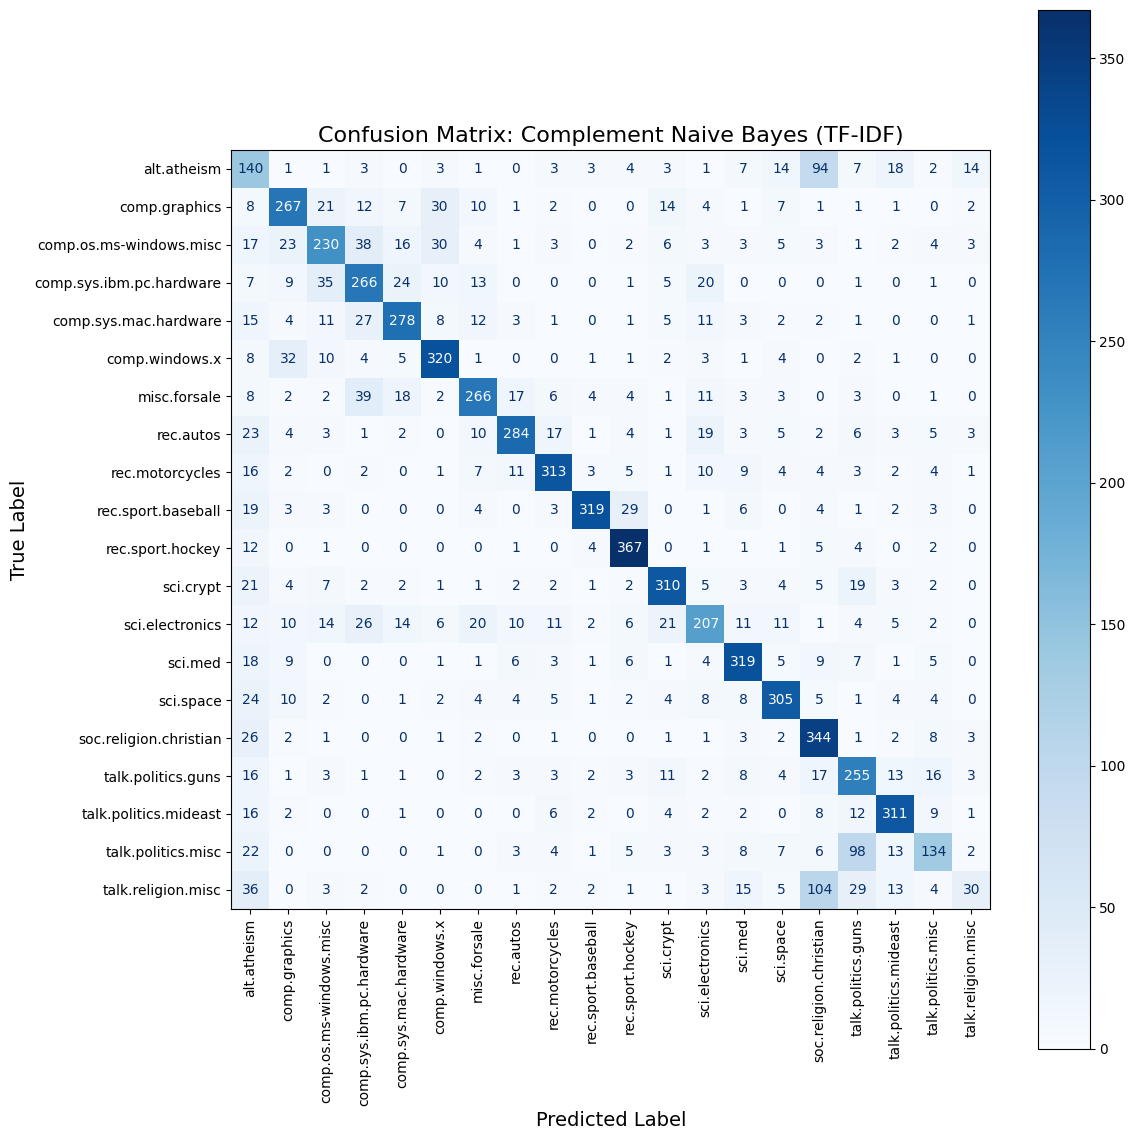

In [14]:
# for fig in confusion_figures_tfidf:
#     display(fig)

for name, _ in classifiers:
    fig, ax = plt.subplots(figsize=(12, 12))  # Larger figure for better readability
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        classifiers_predictions[name],
        display_labels=target_names,  # Use your list of class names
        cmap='Blues',                 # Friendlier color map
        values_format='d',            # Show integer counts
        xticks_rotation='vertical',   # Rotate x-ticks if labels overlap
        ax=ax,
        colorbar=True
    )
    ax.set_title(f"Confusion Matrix: {name} (TF-IDF)", fontsize=16)
    ax.set_xlabel("Predicted Label", fontsize=14)
    ax.set_ylabel("True Label", fontsize=14)
    plt.tight_layout()  # Ensures labels and titles fit nicely
    plt.show()

## Dimensionality Reduction
As we know, our training data contains 13171 features(possible terms) in the sparse matrix. 
Most documents will contain only a small fraction of the possible terms, with most entries being zero.
We want to check if dimension reduction might help us getting rid of less important features that might add noise, prevent overfitting, prevent models from memorizing data patterns that don't generalize, etc. It seems quite logical to us that maintaining a reasonable amount of explained variance (70%) of the original data after the dimensionality reduction will help us get better results, so lets check what would be the number of features that which will give us that 70% explained variance.


Optimal n_components based on 70% explained variance: 1704


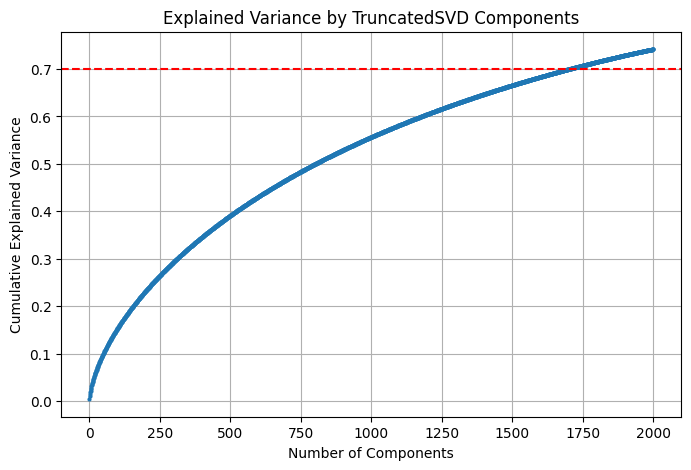

In [ ]:
#reducing dimensions

import numpy as np

class ShiftTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Determine the shift value needed to make all values non-negative
        self.shift_ = -X.min() if X.min() < 0 else 0
        return self

    def transform(self, X, y=None):
        return X + self.shift_
    
# --- Optimal n_components Selection via Explained Variance Analysis ---
# Set a high number of components to analyze the explained variance
max_components = 2000
svd_full = TruncatedSVD(n_components=max_components, random_state=42)
svd_full.fit(X_train_tfidf)
cumulative_variance = np.cumsum(svd_full.explained_variance_ratio_)
# Set threshold for desired explained variance (e.g., 70%)
threshold = 0.70
optimal_n_components = np.argmax(cumulative_variance >= threshold) + 1  # +1 because index starts at 0

plt.close('all')
print(f"\nOptimal n_components based on {threshold*100:.0f}% explained variance: {optimal_n_components}")
# Optional: Plot the cumulative explained variance curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_components + 1), cumulative_variance, marker='o', markersize=2)
plt.axhline(y=threshold, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by TruncatedSVD Components')
plt.grid(True)
plt.show()

We got that 1704 components will get us that 70%, so lets run TruncatedSVD with `n_components=1704` and put our classifiers to the test.

In [ ]:
# --- SVD Pipeline Testing with Optimal n_components and other values ---
svd_results = []

print(f"\n=== Running SVD with n_components={optimal_n_components} ===\n")

# Create SVD pipeline
svd_pipeline = make_pipeline(
    TruncatedSVD(n_components=optimal_n_components, random_state=42),
    ShiftTransformer(),          # Shift data to remove negatives
    Normalizer(copy=False)       # Normalizer is important for kNN and Naive Bayes
)

# Apply SVD transformation
X_train_svd = svd_pipeline.fit_transform(X_train_tfidf)
X_test_svd = svd_pipeline.transform(X_test_tfidf)


svd_results, confusion_figures_svd = evaluate_classifiers(
    classifiers, X_train_svd, X_test_svd, y_train, y_test, "SVD Reduced"
)
results_df_svd = pd.DataFrame(svd_results)
results_df_svd['Dimensions'] = "SVD Reduced"
styled_df_svd = (
    format_results_table(results_df_svd, groupby='n_components').style
    .set_caption("Results for SVD Reduced Data")
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })
)
display(styled_df_svd)


=== Running SVD with n_components=1704 ===


=== Running classifiers on SVD Reduced data (1704 features) ===

Completed: Logistic Regression on SVD Reduced data
Completed: Decision Tree on SVD Reduced data
Completed: Random Forest on SVD Reduced data
Completed: LinearSVC on SVD Reduced data
Completed: KNN on SVD Reduced data
Completed: Multinomial Naive Bayes on SVD Reduced data
Completed: Complement Naive Bayes on SVD Reduced data


C:\Users\benam\AppData\Local\Temp\ipykernel_9996\110695388.py:44: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 8))


,Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),Dimensions,n_components
3,LinearSVC,64.03%,63.64%,64.03%,62.46%,19.198493,SVD Reduced,1704
6,Complement Naive Bayes,63.00%,63.48%,63.00%,61.71%,0.070400,SVD Reduced,1704
2,Random Forest,56.12%,56.29%,56.12%,55.12%,169.669846,SVD Reduced,1704
0,Logistic Regression,50.52%,58.42%,50.52%,47.19%,1.805847,SVD Reduced,1704
1,Decision Tree,36.56%,36.87%,36.56%,36.53%,48.308537,SVD Reduced,1704
4,KNN,14.46%,21.27%,14.46%,15.06%,0.025927,SVD Reduced,1704
5,Multinomial Naive Bayes,11.46%,22.97%,11.46%,6.65%,0.071422,SVD Reduced,1704


Although we expected that reducing the dimensionality from 13,171 to 1,704 features might improve performance and lower training times, we found the opposite. First, many of the chosen classifiers (e.g., Multinomial Naive Bayes, Complement Naive Bayes, and LinearSVC) handle high-dimensional, sparse data very effectively for text tasks. When we apply TruncatedSVD, we risk losing valuable discriminative information, causing a drop in accuracy.

Second, after SVD, the data becomes dense rather than sparse, which can actually slow down training for certain models, such as tree-based classifiers (Decision Tree, Random Forest) and KNN. This overhead can outweigh the benefit of having fewer dimensions. So while dimensionality reduction can be beneficial in some contexts, it can also degrade both speed and accuracy when working with text data and classifiers that naturally handle high-dimensional, sparse input.



## Hyperparameter Optimization Using GridSearchCV
The parameters we initially gave to the classifiers where generic and not optimized, so in this stage we will use GridSearchCV in order to find the optimal parameters for each classifier so we can get the best out of them and we will use them from now on.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define classifiers along with their parameter grids
classifiers_to_opt = [
    ('Logistic Regression', 
     LogisticRegression(random_state=42, max_iter=1000),
     {'C': [0.1, 1, 10, 100],
      'solver': ['lbfgs', 'liblinear']}),
    
    ('Decision Tree', 
     DecisionTreeClassifier(random_state=42),
     {'max_depth': [None, 5, 10, 20],
      'min_samples_split': [2, 5, 10],
      'min_samples_leaf': [1, 2, 4],
      'max_features': [None, 'sqrt', 'log2']}),
    
    ('Random Forest', 
     RandomForestClassifier(random_state=42),
     {'n_estimators': [20, 50, 100],
      'max_features': ['sqrt', 'log2'],
      'max_depth': [None, 5, 10, 20]}),
    
    ('LinearSVC', 
     LinearSVC(random_state=42, dual=True, max_iter=10000),
     {'C': [0.01, 0.1, 1, 10, 100]}),
    
    ('KNN', 
     KNeighborsClassifier(),
     {'n_neighbors': [5, 7, 9, 11],
      'weights': ['uniform', 'distance'],
      'metric': ['euclidean', 'manhattan', 'cosine']}),
    
    ('Naive Bayes', 
    #  MultinomialNB(),
     GaussianNB(),
    {'var_smoothing': [1e-9, 1e-8]})
]

# Dictionary to store the grid search results for each classifier
grid_search_results = {}

# Loop over classifiers and perform grid search
for name, clf, param_grid in classifiers_to_opt:
    print(f"Running GridSearchCV for {name}...")
    grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_tfidf, y_train)
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    print(f"Best cross-validation score for {name}: {grid_search.best_score_:.4f}\n")
    grid_search_results[name] = grid_search

Running GridSearchCV for Logistic Regression...


: 

In [ ]:
# Evaluate each optimized (best) classifier on the test set using your evaluation functions
optimized_results = []
optimized_confusion_figures = []
print("\n=== Evaluating Optimized Classifiers on TF-IDF Data ===\n")
for clf_name, grid in grid_search_results.items():
    best_model = grid.best_estimator_ # This model has the optimal parameters
    result = get_classifier_metrics(best_model, X_train_tfidf, X_test_tfidf, y_train, y_test, clf_name, to_fit=False)
    result['Best Parameters'] = grid.best_params_
    result['Dimensions'] = 'Original (No Reduction)'
    result['n_components'] = X_train_tfidf.shape[1]
    optimized_results.append(result)
    print(f"Completed: {clf_name} (Optimized)")
    fig = plot_confusion_matrix(y_test, result['y_pred'], clf_name, "TF-IDF (Optimized)")
    optimized_confusion_figures.append(fig)

# Create and display a formatted results table for the optimized classifiers
results_df_optimized = pd.DataFrame(optimized_results)
styled_df_optimized = format_results_table(results_df_optimized, groupby='n_components').style \
    .set_caption("Results for Optimized TF-IDF Data") \
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })

styled_df_optimized.hide()
display(styled_df_optimized.hide())


=== Evaluating Optimized Classifiers on TF-IDF Data ===

Completed: Logistic Regression (Optimized)
Completed: Decision Tree (Optimized)
Completed: Random Forest (Optimized)
Completed: LinearSVC (Optimized)
Completed: KNN (Optimized)
Completed: Naive Bayes (Optimized)


Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),Best Parameters,Dimensions,n_components
Logistic Regression,65.53%,66.05%,65.53%,65.48%,0.000000,"{'C': 1, 'solver': 'lbfgs'}",Original (No Reduction),13171
LinearSVC,65.40%,65.60%,65.40%,64.91%,0.000000,{'C': 0.1},Original (No Reduction),13171
Random Forest,56.35%,56.04%,56.35%,55.53%,0.000000,"{'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}",Original (No Reduction),13171
KNN,53.69%,54.25%,53.69%,53.53%,0.000000,"{'metric': 'cosine', 'n_neighbors': 11, 'weights': 'distance'}",Original (No Reduction),13171
Naive Bayes,52.77%,59.03%,52.77%,54.38%,0.000000,{'var_smoothing': 1e-09},Original (No Reduction),13171
Decision Tree,37.90%,38.93%,37.90%,38.13%,0.000000,"{'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}",Original (No Reduction),13171


## Confusion
It is interesting to see which classes are causing the classifiers to make mistakes and also we want to see how the classifiers did with the minority classes compared to the majority ones.

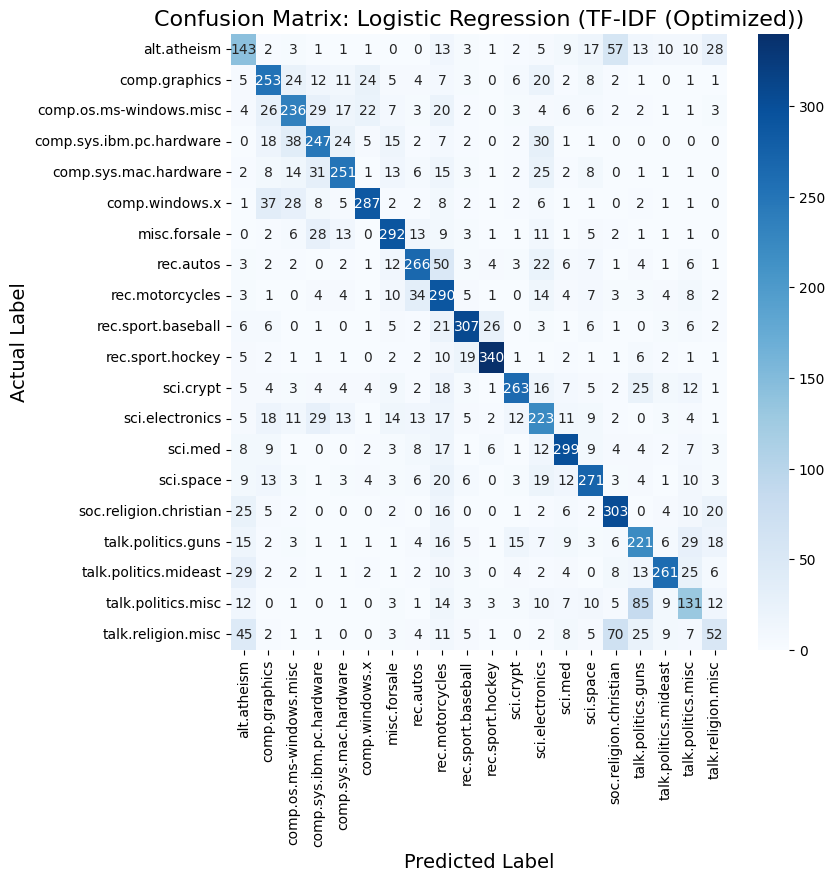

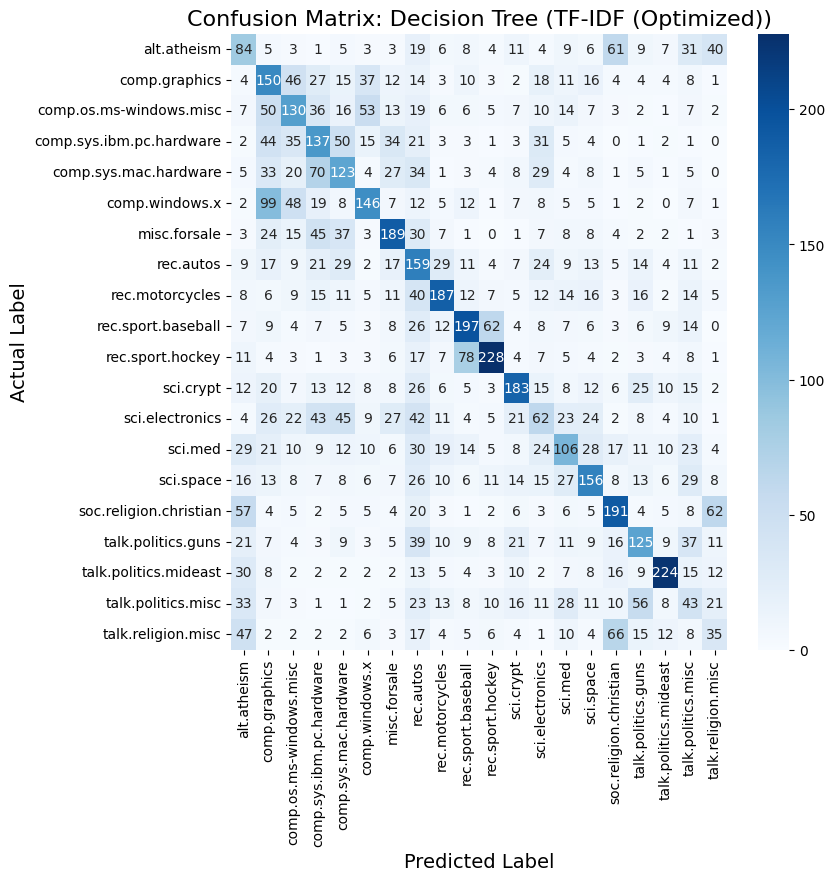

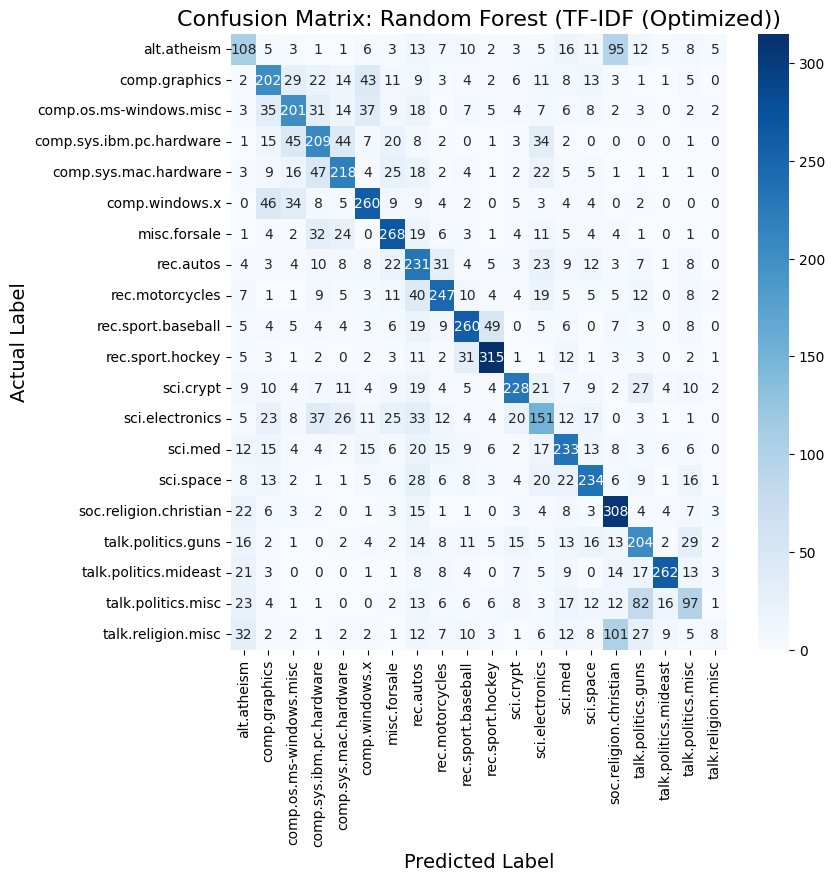

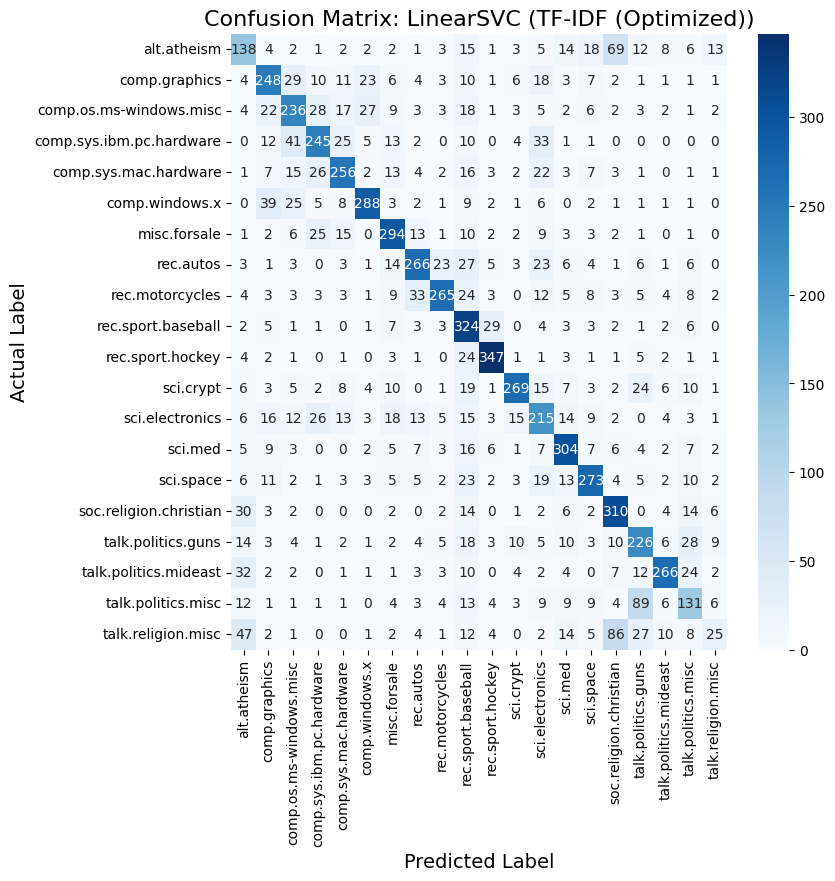

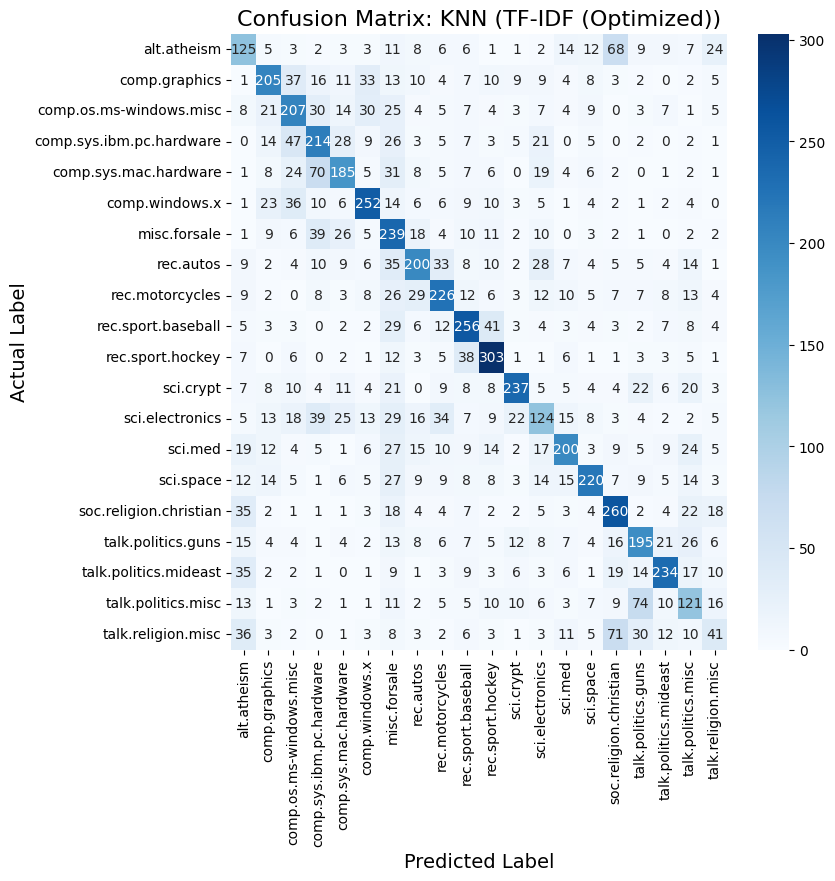

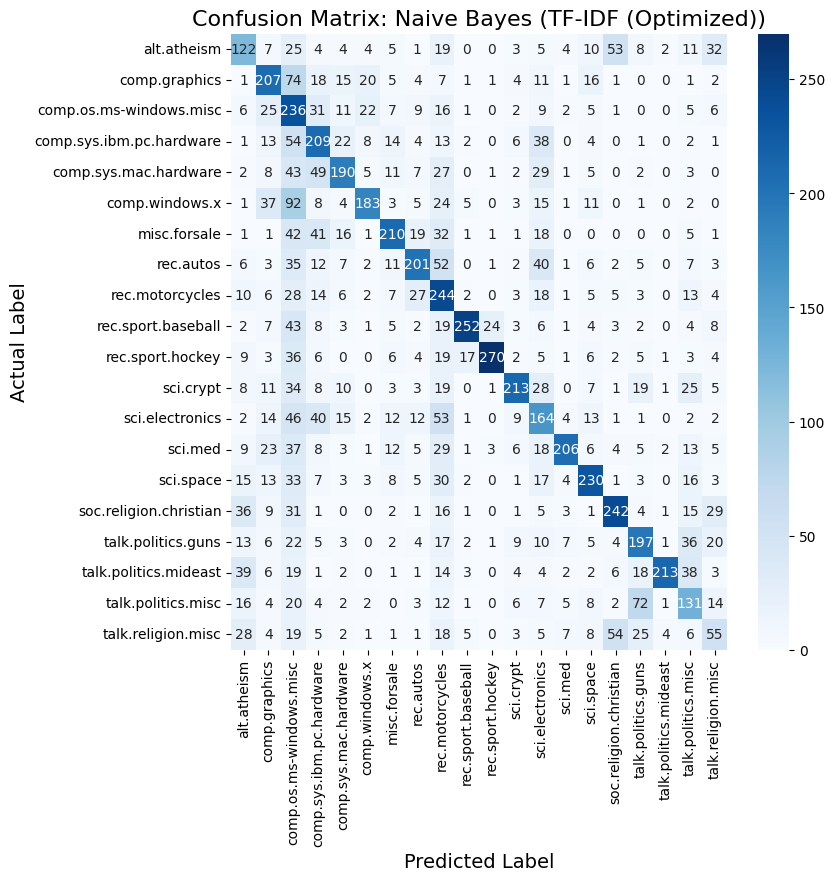

In [ ]:
for fig in optimized_confusion_figures:
    display(fig)


## 5. Dimensionality Reduction - High vs Low explained variance
As we know, our training data contains 13171 features(possible terms) in the sparse matrix. Most documents will contain only a small fraction of the possible terms, with most entries being zero.
We want to check if dimension reduction might help us getting rid of less important features that might add noise, prevent overfitting, prevent models from memorizing data patterns that don't generalize, etc. It seems quite logical to us that maintaining a reasonable amount of explained variance (70%) of the original data after the dimensionality reduction, will help us get better results with our classifiers than on low values of explained variance, but is that so ? 


Optimal n_components based on 70% explained variance: 1704


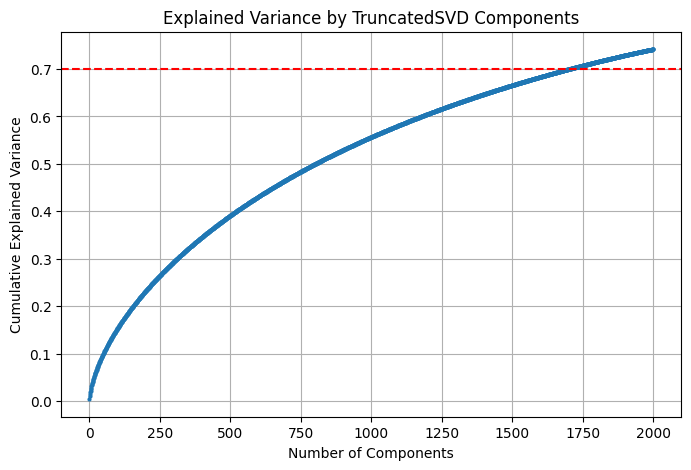

In [ ]:
import numpy as np
# Define a custom transformer to shift the data to make it non-negative (might happen after dimensionality reduction)
# This is important for Naive Bayes and kNN classifiers
class ShiftTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Determine the shift value needed to make all values non-negative
        self.shift_ = -X.min() if X.min() < 0 else 0
        return self

    def transform(self, X, y=None):
        return X + self.shift_
    
# --- Optimal n_components Selection via Explained Variance Analysis ---
# Set a high number of components to analyze the explained variance
max_components = 2000
svd_full = TruncatedSVD(n_components=max_components, random_state=42)
svd_full.fit(X_train_tfidf)
cumulative_variance = np.cumsum(svd_full.explained_variance_ratio_)
# Set threshold for desired explained variance (e.g., 70%)
threshold = 0.70
optimal_n_components = np.argmax(cumulative_variance >= threshold) + 1  # +1 because index starts at 0

plt.close('all')
print(f"\nOptimal n_components based on {threshold*100:.0f}% explained variance: {optimal_n_components}")
# Optional: Plot the cumulative explained variance curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_components + 1), cumulative_variance, marker='o', markersize=2)
plt.axhline(y=threshold, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by TruncatedSVD Components')
plt.grid(True)
plt.show()

Lets use this number of components that achieves 70% explained variance and see how our results will be affected.

In [ ]:
# --- SVD Pipeline Testing with Optimal n_components and other values ---
svd_results = []

print(f"\n=== Running SVD with n_components={optimal_n_components} ===\n")

# Create SVD pipeline
svd_pipeline = make_pipeline(
    TruncatedSVD(n_components=optimal_n_components, random_state=42),
    ShiftTransformer(),          # Shift data to remove negatives
    Normalizer(copy=False)       # Normalizer is important for kNN and Naive Bayes
)

# Apply SVD transformation
X_train_svd = svd_pipeline.fit_transform(X_train_tfidf)
X_test_svd = svd_pipeline.transform(X_test_tfidf)

# Get explained variance ratio
svd = svd_pipeline.named_steps['truncatedsvd']
explained_variance = svd.explained_variance_ratio_.sum()
print(f"SVD with {optimal_n_components} components explains {explained_variance:.2%} of variance")

# Test each optimized classifier on the reduced data
# (Assuming grid_search_results contains your GridSearchCV objects from earlier)
for clf_name, grid in grid_search_results.items():
    best_model = grid.best_estimator_  # Optimized classifier
    try:
        # Here we let the model fit on the SVD data
        result = get_classifier_metrics(best_model, X_train_svd, X_test_svd, y_train, y_test, clf_name)
        result['Dimensions'] = 'SVD'
        result['n_components'] = optimal_n_components
        result['Explained Variance'] = explained_variance
        svd_results.append(result)
        print(f"Completed: {clf_name} with n_components={optimal_n_components}")
    except Exception as e:
        print(f"Error with {clf_name} on n_components={optimal_n_components}: {e}")

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(svd_results)

# Filter results for SVD dimensionality reduction
svd_results_df = results_df[results_df['Dimensions'] == 'SVD']

# Display table for SVD reduced data results without row numbers
styled_df = format_results_table(svd_results_df, groupby='n_components').style\
    .set_caption("=== Results for SVD Reduced Data ===")\
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })

display(styled_df.hide())


=== Running SVD with n_components=1704 ===

SVD with 1704 components explains 69.75% of variance
Completed: Logistic Regression with n_components=1704
Completed: Decision Tree with n_components=1704
Completed: Random Forest with n_components=1704
Completed: LinearSVC with n_components=1704
Completed: KNN with n_components=1704
Completed: Naive Bayes with n_components=1704


Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),Dimensions,n_components,Explained Variance
LinearSVC,58.94%,56.78%,58.94%,55.81%,36.765560,SVD,1704,0.697541
Random Forest,53.53%,53.14%,53.53%,52.52%,246.339508,SVD,1704,0.697541
Logistic Regression,50.52%,58.42%,50.52%,47.19%,3.249035,SVD,1704,0.697541
Naive Bayes,38.16%,54.79%,38.16%,41.40%,0.440745,SVD,1704,0.697541
Decision Tree,37.33%,38.53%,37.33%,37.59%,142.829731,SVD,1704,0.697541
KNN,13.20%,21.68%,13.20%,13.84%,0.047526,SVD,1704,0.697541


Let's see what we will get with lower values of explained variance.
We will run the TruncatedSVD with ```n_components``` values of ```150,350,500``` which gives explained variance values of 

In [ ]:
# --- SVD Pipeline Testing with Optimal n_components and other values ---
svd_results = []

n_components_list = [150,300,450]

# Run SVD with different n_components values
for n_components in n_components_list:
    print(f"\n=== Running SVD with n_components={n_components} ===\n")
    
    # Create SVD pipeline
    svd_pipeline = make_pipeline(
        TruncatedSVD(n_components=n_components, random_state=42),
        ShiftTransformer(),
        Normalizer(copy=False)
    )
    
    # Apply SVD transformation
    X_train_svd = svd_pipeline.fit_transform(X_train_tfidf)
    X_test_svd = svd_pipeline.transform(X_test_tfidf)
    
    # Get explained variance ratio
    svd = svd_pipeline.named_steps['truncatedsvd']
    explained_variance = svd.explained_variance_ratio_.sum()
    print(f"SVD with {n_components} components explains {explained_variance:.2%} of variance")
    
    # Test each classifier on the reduced data
    for clf_name, grid in grid_search_results.items():
        best_model = grid.best_estimator_  # Optimized classifier
        try:
        # Here we let the model fit on the SVD data
            result = get_classifier_metrics(best_model, X_train_svd, X_test_svd, y_train, y_test, clf_name)
            result['Dimensions'] = 'SVD'
            result['n_components'] = n_components
            result['Explained Variance'] = explained_variance
            svd_results.append(result)
            print(f"Completed: {clf_name} with n_components={n_components}")
        except Exception as e:
            print(f"Error with {clf_name} on n_components={n_components}: {e}")


# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(svd_results)

# Filter results for SVD dimensionality reduction
svd_results = results_df[results_df['Dimensions'] == 'SVD'] 

# Display table for SVD reduced data results without row numbers
styled_df = format_results_table(svd_results, groupby='n_components').style\
    .set_caption("=== Results for SVD Reduced Data ===")\
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })

display(styled_df.hide())



=== Running SVD with n_components=150 ===

SVD with 150 components explains 19.28% of variance
Completed: Logistic Regression with n_components=150
Completed: Decision Tree with n_components=150
Completed: Random Forest with n_components=150
Completed: LinearSVC with n_components=150
Completed: KNN with n_components=150
Completed: Naive Bayes with n_components=150

=== Running SVD with n_components=300 ===

SVD with 300 components explains 29.01% of variance
Completed: Logistic Regression with n_components=300
Completed: Decision Tree with n_components=300
Completed: Random Forest with n_components=300
Completed: LinearSVC with n_components=300
Completed: KNN with n_components=300
Completed: Naive Bayes with n_components=300

=== Running SVD with n_components=450 ===

SVD with 450 components explains 36.49% of variance
Completed: Logistic Regression with n_components=450
Completed: Decision Tree with n_components=450
Completed: Random Forest with n_components=450
Completed: LinearSVC 

Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),Dimensions,n_components,Explained Variance
LinearSVC,60.00%,59.74%,60.00%,58.18%,4.202906,SVD,150,0.192785
Logistic Regression,57.50%,60.16%,57.50%,54.77%,0.380060,SVD,150,0.192785
Random Forest,56.41%,56.22%,56.41%,55.75%,65.983278,SVD,150,0.192785
Naive Bayes,48.35%,53.23%,48.35%,48.91%,0.046587,SVD,150,0.192785
KNN,45.87%,47.58%,45.87%,45.64%,0.032625,SVD,150,0.192785
Decision Tree,38.57%,39.79%,38.57%,38.89%,11.670350,SVD,150,0.192785
LinearSVC,60.66%,61.28%,60.66%,58.68%,2.341909,SVD,300,0.290051
Logistic Regression,57.79%,58.78%,57.79%,54.66%,0.574665,SVD,300,0.290051
Random Forest,56.31%,56.58%,56.31%,55.68%,35.668557,SVD,300,0.290051
Naive Bayes,46.97%,54.68%,46.97%,48.57%,0.051538,SVD,300,0.290051


We can see that even though we get only 29% variance for n_components = 300, we get much better accuracy results compared to n_components = 1699, And a much lower training time.